In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import medfilt, butter, filtfilt, resample_poly
from scipy.fft import fft, ifft, fftfreq
from scipy.interpolate import interp1d

Среднее: 0.0166
Стандартное отклонение: 0.8576
Найдено выбросов: 20


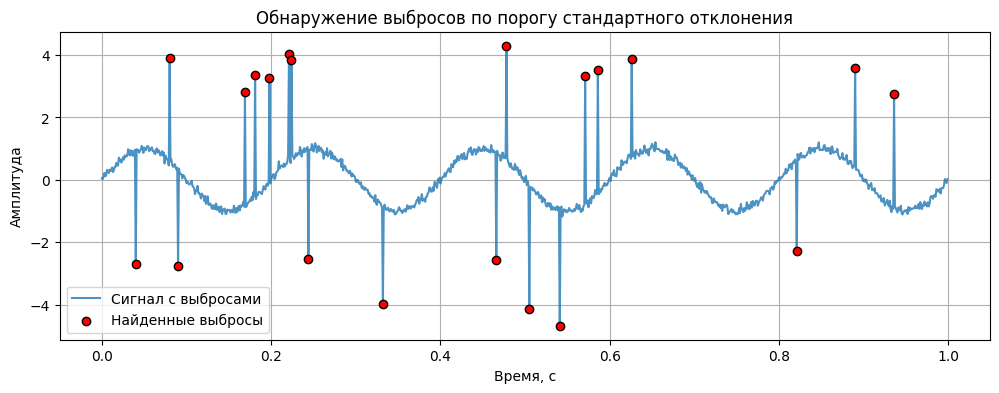

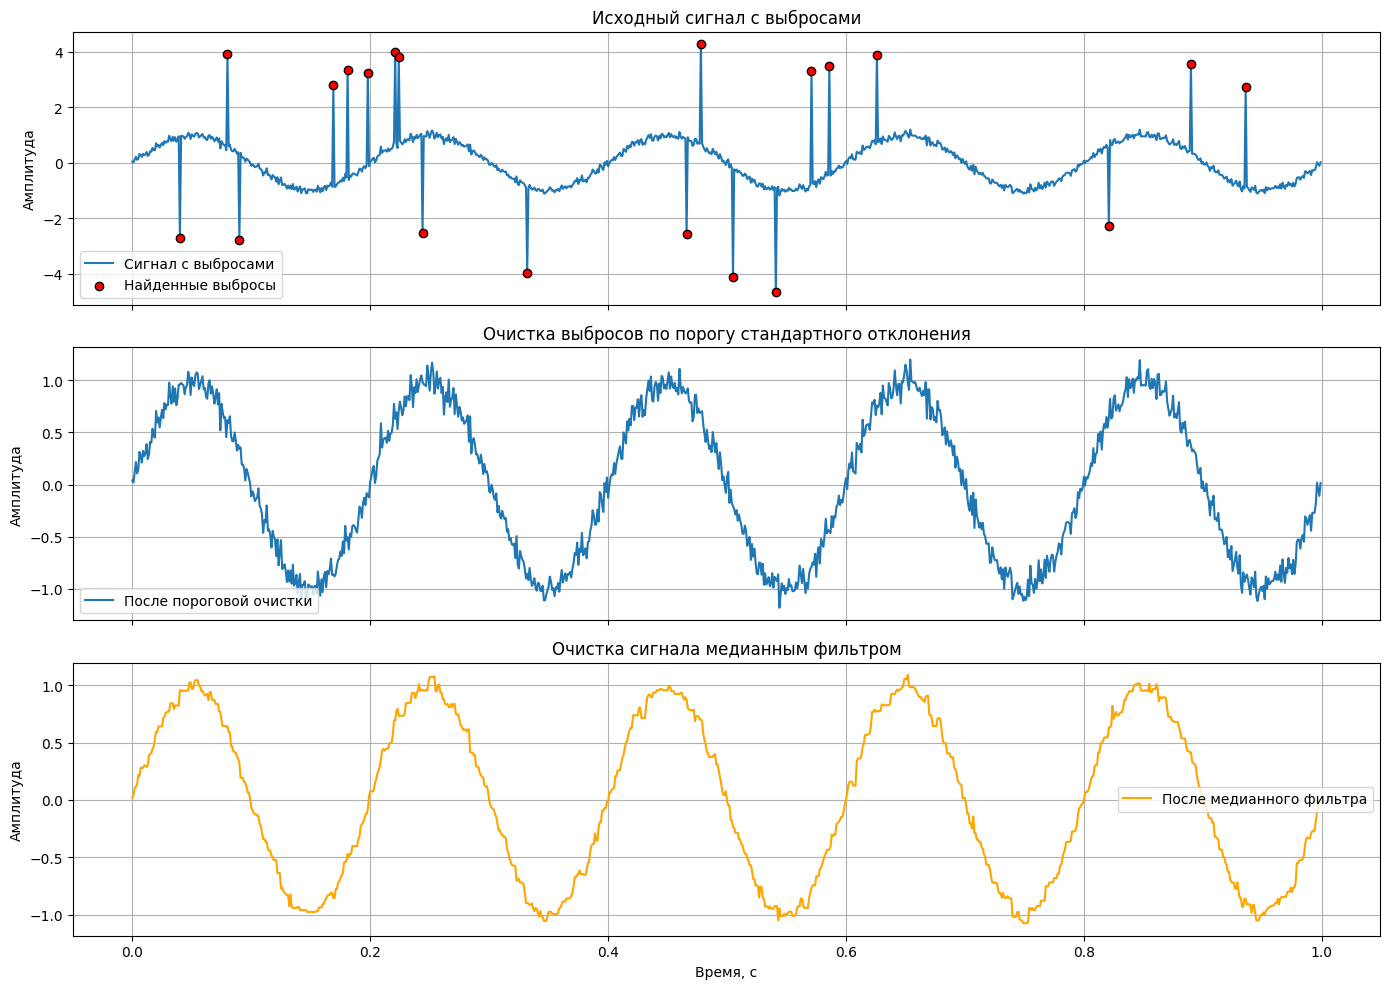

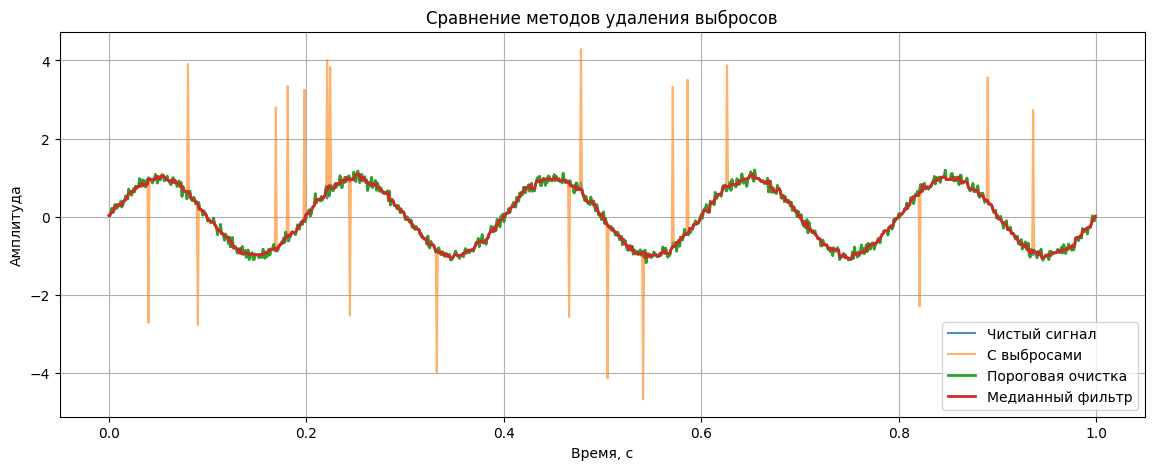

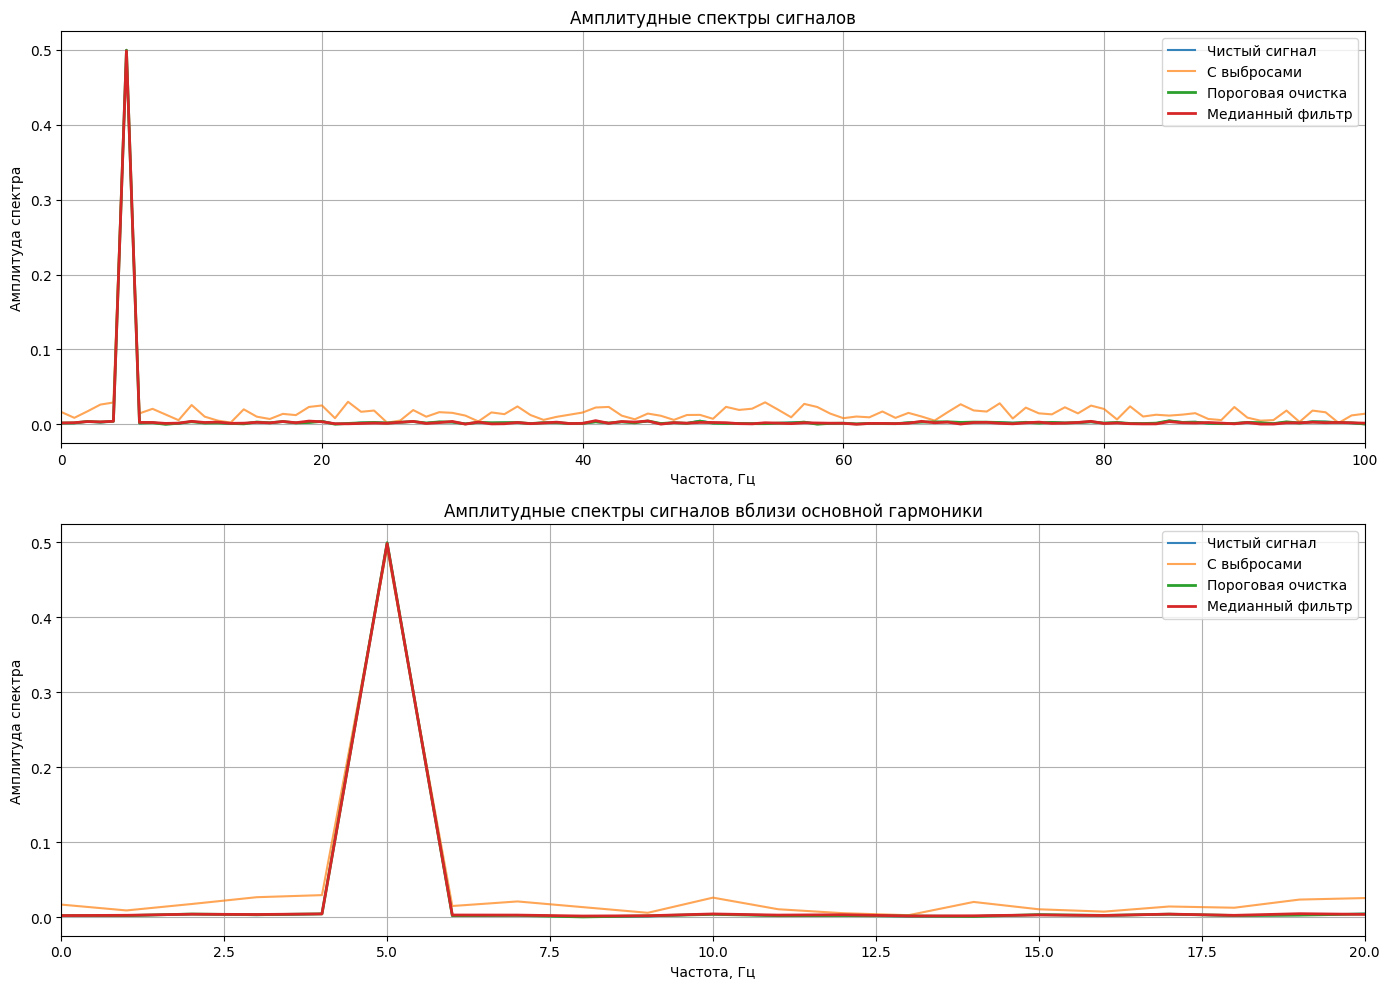

In [18]:
np.random.seed(42)

N = 1000
t = np.linspace(0, 1, N, endpoint=False)

x_clean = np.sin(2 * np.pi * 5 * t) + 0.08 * np.random.randn(N)

x_noisy = x_clean.copy()

n_outliers = 20
outlier_idx = np.random.choice(N, size=n_outliers, replace=False)

outlier_values = np.random.choice([-1, 1], size=n_outliers) * np.random.uniform(3.0, 4.0, size=n_outliers)
x_noisy[outlier_idx] += outlier_values

mean_val = np.mean(x_noisy)
std_val = np.std(x_noisy)

k = 2.0  # порог "трех сигм"


# Маска выбросов
outlier_mask = np.abs(x_noisy - mean_val) > k * std_val


x_threshold = x_noisy.copy()

print(f"Среднее: {mean_val:.4f}")
print(f"Стандартное отклонение: {std_val:.4f}")
print(f"Найдено выбросов: {np.sum(outlier_mask)}")

plt.figure(figsize=(12, 4))
plt.plot(t, x_noisy, label='Сигнал с выбросами', alpha=0.8)
plt.scatter(
    t[outlier_mask],
    x_noisy[outlier_mask],
    label='Найденные выбросы',
    zorder=3,
    color='red',
    edgecolor='black',
)
plt.title('Обнаружение выбросов по порогу стандартного отклонения')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()


window_size = 5
half_window = window_size // 2

for i in np.where(outlier_mask)[0]:
    left = max(0, i - half_window)
    right = min(len(x_noisy), i + half_window + 1)

    local_window = x_noisy[left:right]

    local_mask = ~outlier_mask[left:right]
    valid_values = local_window[local_mask]

    if len(valid_values) > 0:
        x_threshold[i] = np.median(valid_values)
    else:
        x_threshold[i] = np.median(local_window)


# Медианный фильтр для сравнения
x_median = medfilt(x_noisy, kernel_size=5)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, x_noisy, label='Сигнал с выбросами')
axes[0].scatter(t[outlier_mask], x_noisy[outlier_mask],
                color='red', edgecolor='black', zorder=3,
                label='Найденные выбросы')
axes[0].set_title('Исходный сигнал с выбросами')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, x_threshold, label='После пороговой очистки')
axes[1].set_title('Очистка выбросов по порогу стандартного отклонения')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, x_median, label='После медианного фильтра', color='orange')
axes[2].set_title('Очистка сигнала медианным фильтром')
axes[2].set_xlabel('Время, с')
axes[2].set_ylabel('Амплитуда')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(t, x_clean, label='Чистый сигнал', alpha=0.8)
plt.plot(t, x_noisy, label='С выбросами', alpha=0.6)
plt.plot(t, x_threshold, label='Пороговая очистка', linewidth=2)
plt.plot(t, x_median, label='Медианный фильтр', linewidth=2)
plt.title('Сравнение методов удаления выбросов')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

dt = t[1] - t[0]
freqs = np.fft.rfftfreq(N, d=dt)

spec_clean = np.abs(np.fft.rfft(x_clean)) / N
spec_noisy = np.abs(np.fft.rfft(x_noisy)) / N
spec_threshold = np.abs(np.fft.rfft(x_threshold)) / N
spec_median = np.abs(np.fft.rfft(x_median)) / N

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].plot(freqs, spec_clean, label='Чистый сигнал', alpha=0.9)
axes[0].plot(freqs, spec_noisy, label='С выбросами', alpha=0.7)
axes[0].plot(freqs, spec_threshold, label='Пороговая очистка', linewidth=2)
axes[0].plot(freqs, spec_median, label='Медианный фильтр', linewidth=2)
axes[0].set_title('Амплитудные спектры сигналов')
axes[0].set_xlabel('Частота, Гц')
axes[0].set_ylabel('Амплитуда спектра')
axes[0].set_xlim(0, 100)
axes[0].grid(True)
axes[0].legend()

axes[1].plot(freqs, spec_clean, label='Чистый сигнал', alpha=0.9)
axes[1].plot(freqs, spec_noisy, label='С выбросами', alpha=0.7)
axes[1].plot(freqs, spec_threshold, label='Пороговая очистка', linewidth=2)
axes[1].plot(freqs, spec_median, label='Медианный фильтр', linewidth=2)
axes[1].set_title('Амплитудные спектры сигналов вблизи основной гармоники')
axes[1].set_xlabel('Частота, Гц')
axes[1].set_ylabel('Амплитуда спектра')
axes[1].set_xlim(0, 20)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

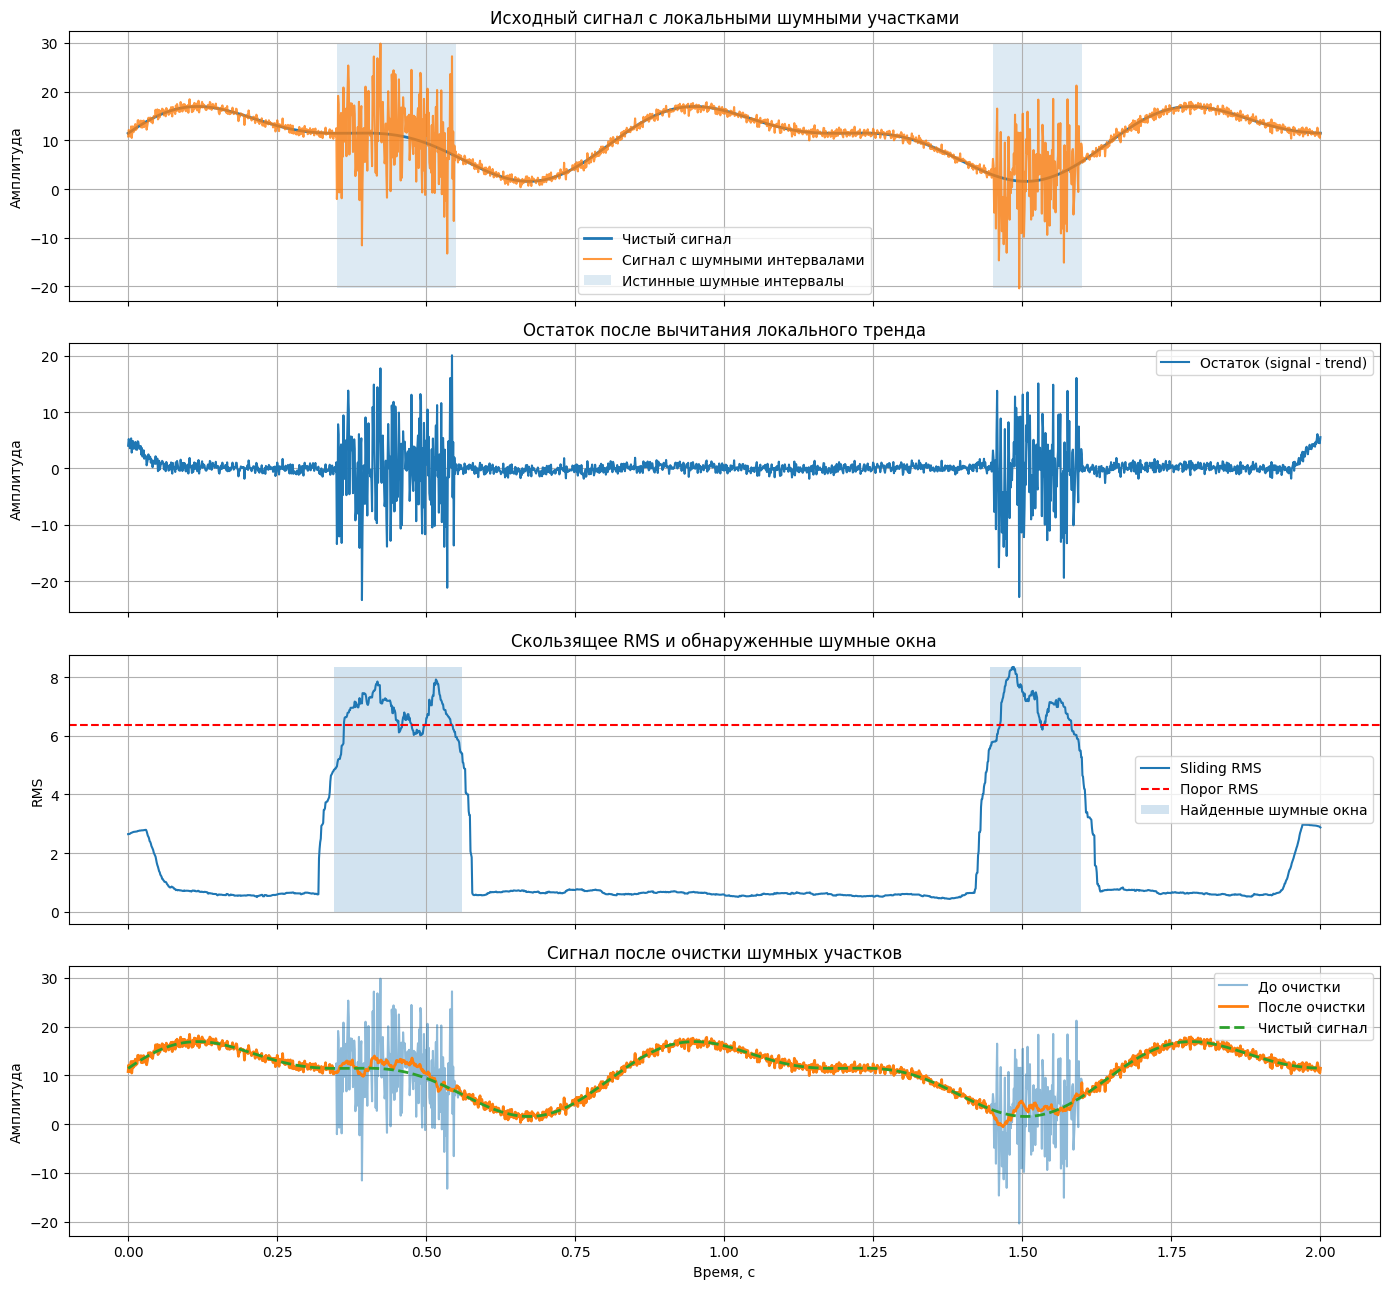

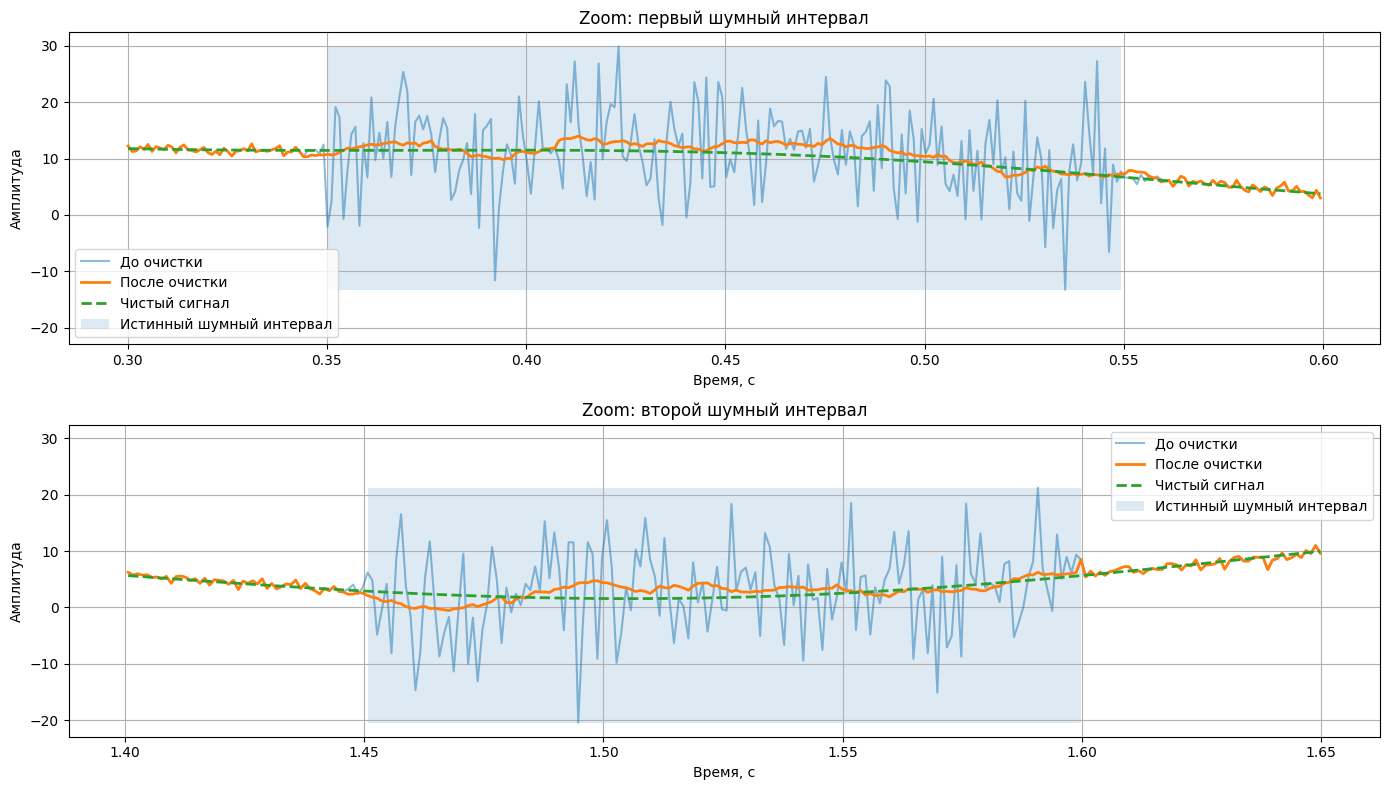

Порог RMS: 6.371
Число точек, попавших в шумные окна: 369
RMSE до очистки: 3.109
RMSE после очистки: 0.803


In [9]:
### Задание 2
# Сигнал с локальными шумными участками и очистка через sliding RMS

np.random.seed(123)

N2 = 2000
t2 = np.linspace(0, 2, N2)

x2_clean = (
    10
    + 6 * np.sin(2 * np.pi * 1.2 * t2)
    + 3 * np.sin(2 * np.pi * 2.4 * t2 + 0.5)
)

x2_base = x2_clean + 0.6 * np.random.randn(N2)

true_noise_mask2 = (
    ((t2 >= 0.35) & (t2 <= 0.55)) |
    ((t2 >= 1.45) & (t2 <= 1.60))
)

x2_noisy = x2_base.copy()
x2_noisy[true_noise_mask2] += 7.5 * np.random.randn(np.sum(true_noise_mask2))


trend_window2 = 101
trend_kernel2 = np.ones(trend_window2) / trend_window2
x2_trend = np.convolve(x2_noisy, trend_kernel2, mode='same')
x2_residual = x2_noisy - x2_trend

rms_window2 = 61
rms_kernel2 = np.ones(rms_window2) / rms_window2
rms2 = np.sqrt(np.convolve(x2_residual**2, rms_kernel2, mode='same'))

rms_threshold2 = np.mean(rms2) + 1.8 * np.std(rms2)

noisy_windows_mask2 = rms2 > rms_threshold2

expand_window2 = 35
expand_kernel2 = np.ones(expand_window2)
noisy_windows_mask2 = np.convolve(
    noisy_windows_mask2.astype(int),
    expand_kernel2,
    mode='same'
) > 0

smooth_window2 = 31
smooth_kernel2 = np.ones(smooth_window2) / smooth_window2
x2_smooth = np.convolve(x2_noisy, smooth_kernel2, mode='same')

x2_filtered = x2_noisy.copy()
x2_filtered[noisy_windows_mask2] = x2_smooth[noisy_windows_mask2]

rmse_before2 = np.sqrt(np.mean((x2_noisy - x2_clean) ** 2))
rmse_after2 = np.sqrt(np.mean((x2_filtered - x2_clean) ** 2))

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

# График 1: чистый и зашумленный сигнал
axes[0].plot(t2, x2_clean, label='Чистый сигнал', linewidth=2)
axes[0].plot(t2, x2_noisy, label='Сигнал с шумными интервалами', alpha=0.8)
axes[0].fill_between(
    t2,
    np.min(x2_noisy),
    np.max(x2_noisy),
    where=true_noise_mask2,
    alpha=0.15,
    label='Истинные шумные интервалы'
)
axes[0].set_title('Исходный сигнал с локальными шумными участками')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

# График 2: остаток после вычитания тренда
axes[1].plot(t2, x2_residual, label='Остаток (signal - trend)')
axes[1].set_title('Остаток после вычитания локального тренда')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

# График 3: sliding RMS и порог
axes[2].plot(t2, rms2, label='Sliding RMS')
axes[2].axhline(rms_threshold2, color='red', linestyle='--', label='Порог RMS')
axes[2].fill_between(
    t2,
    0,
    np.max(rms2),
    where=noisy_windows_mask2,
    alpha=0.2,
    label='Найденные шумные окна'
)
axes[2].set_title('Скользящее RMS и обнаруженные шумные окна')
axes[2].set_ylabel('RMS')
axes[2].grid(True)
axes[2].legend()

# График 4: результат очистки
axes[3].plot(t2, x2_noisy, label='До очистки', alpha=0.5)
axes[3].plot(t2, x2_filtered, label='После очистки', linewidth=2)
axes[3].plot(t2, x2_clean, label='Чистый сигнал', linewidth=2, linestyle='--')
axes[3].set_title('Сигнал после очистки шумных участков')
axes[3].set_xlabel('Время, с')
axes[3].set_ylabel('Амплитуда')
axes[3].grid(True)
axes[3].legend()

plt.tight_layout()
plt.show()

zoom1_mask2 = (t2 >= 0.30) & (t2 <= 0.60)
zoom2_mask2 = (t2 >= 1.40) & (t2 <= 1.65)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)

axes[0].plot(t2[zoom1_mask2], x2_noisy[zoom1_mask2], label='До очистки', alpha=0.5)
axes[0].plot(t2[zoom1_mask2], x2_filtered[zoom1_mask2], label='После очистки', linewidth=2)
axes[0].plot(t2[zoom1_mask2], x2_clean[zoom1_mask2], label='Чистый сигнал', linewidth=2, linestyle='--')
axes[0].fill_between(
    t2[zoom1_mask2],
    np.min(x2_noisy[zoom1_mask2]),
    np.max(x2_noisy[zoom1_mask2]),
    where=true_noise_mask2[zoom1_mask2],
    alpha=0.15,
    label='Истинный шумный интервал'
)
axes[0].set_title('Zoom: первый шумный интервал')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t2[zoom2_mask2], x2_noisy[zoom2_mask2], label='До очистки', alpha=0.5)
axes[1].plot(t2[zoom2_mask2], x2_filtered[zoom2_mask2], label='После очистки', linewidth=2)
axes[1].plot(t2[zoom2_mask2], x2_clean[zoom2_mask2], label='Чистый сигнал', linewidth=2, linestyle='--')
axes[1].fill_between(
    t2[zoom2_mask2],
    np.min(x2_noisy[zoom2_mask2]),
    np.max(x2_noisy[zoom2_mask2]),
    where=true_noise_mask2[zoom2_mask2],
    alpha=0.15,
    label='Истинный шумный интервал'
)
axes[1].set_title('Zoom: второй шумный интервал')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Порог RMS: {rms_threshold2:.3f}')
print(f'Число точек, попавших в шумные окна: {np.sum(noisy_windows_mask2)}')
print(f'RMSE до очистки: {rmse_before2:.3f}')
print(f'RMSE после очистки: {rmse_after2:.3f}')

Найденный разрыв: [398, 507)
Длина разрыва: 109 точек


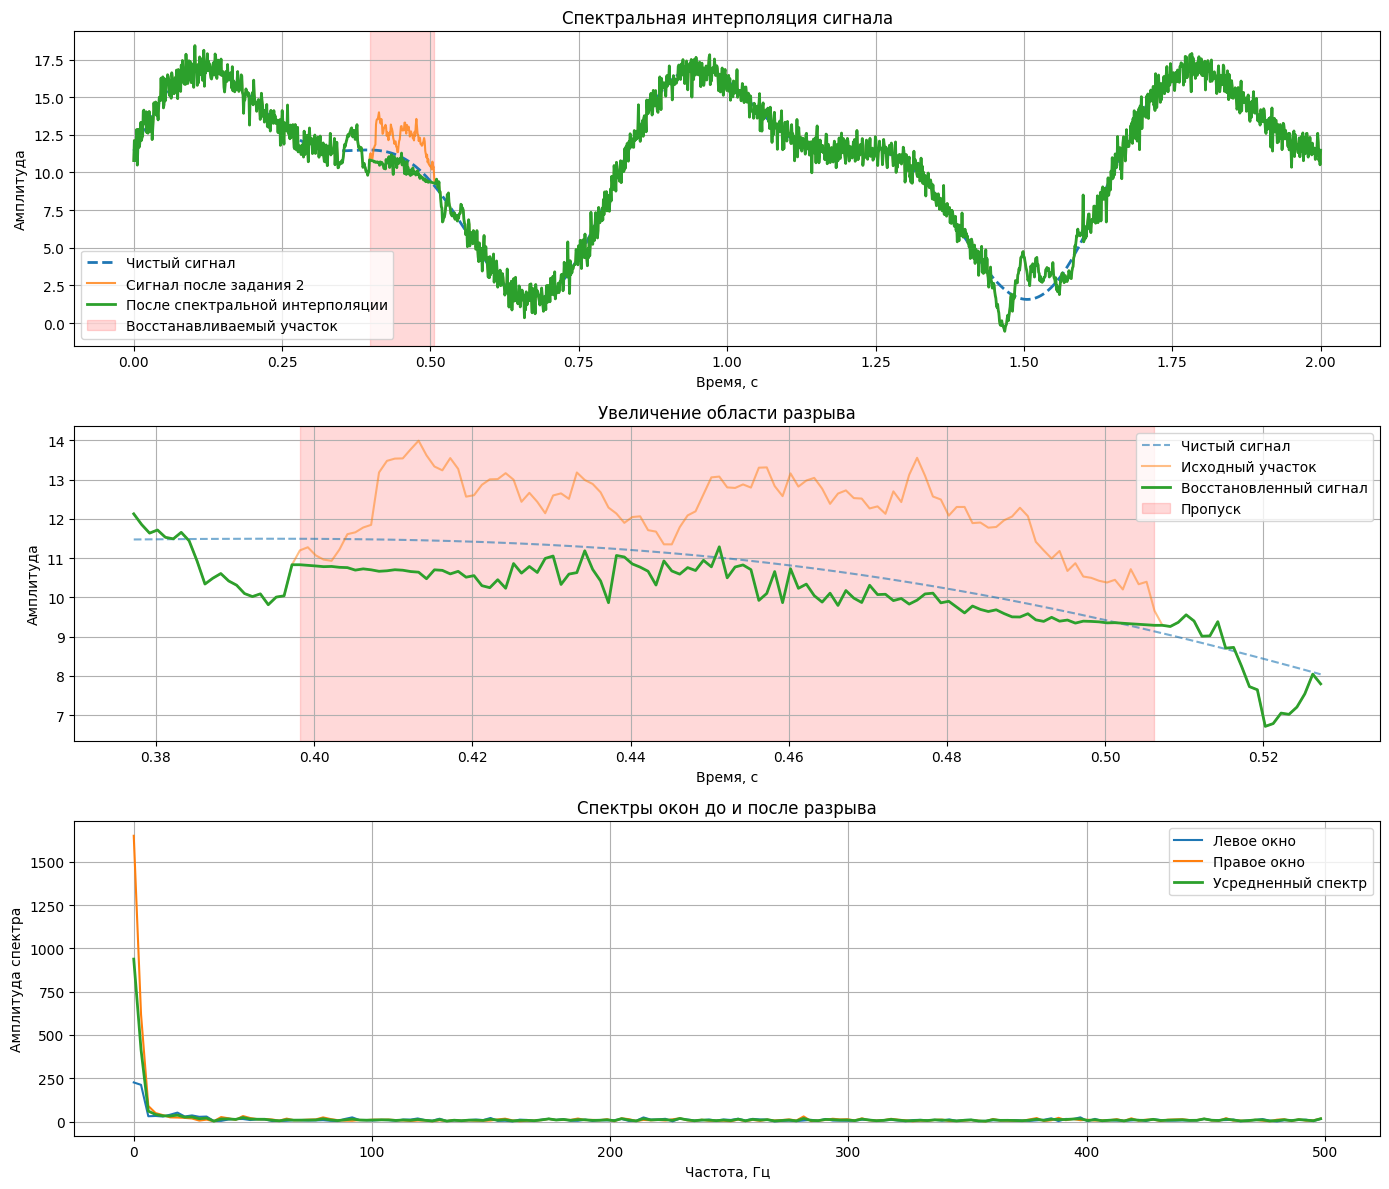

RMSE на участке разрыва: 0.593


In [12]:
### Задание 3
# Спектральная интерполяция потерянного участка сигнала

x3_source = x2_filtered.copy()

mask3 = noisy_windows_mask2.astype(int)
diff3 = np.diff(np.r_[0, mask3, 0])

starts3 = np.where(diff3 == 1)[0]
ends3 = np.where(diff3 == -1)[0]

segment_lengths3 = ends3 - starts3
largest_seg_idx3 = np.argmax(segment_lengths3)

full_gap_start3 = starts3[largest_seg_idx3]
full_gap_end3 = ends3[largest_seg_idx3]

full_gap_len3 = full_gap_end3 - full_gap_start3
trim3 = full_gap_len3 // 4

gap_start3 = full_gap_start3 + trim3
gap_end3 = full_gap_end3 - trim3
gap_len3 = gap_end3 - gap_start3

print(f'Найденный разрыв: [{gap_start3}, {gap_end3})')
print(f'Длина разрыва: {gap_len3} точек')

x3_with_gap = x3_source.copy()
x3_with_gap[gap_start3:gap_end3] = np.nan

window_len3 = min(3 * gap_len3, gap_start3, len(x3_source) - gap_end3)

left_start3 = gap_start3 - window_len3
left_end3 = gap_start3

right_start3 = gap_end3
right_end3 = gap_end3 + window_len3

if left_start3 < 0 or right_end3 > len(x3_source):
    raise ValueError("Недостаточно точек слева или справа от разрыва для спектральной интерполяции.")

left_window3 = x3_source[left_start3:left_end3]
right_window3 = x3_source[right_start3:right_end3]

left_trend3 = np.linspace(left_window3[0], left_window3[-1], window_len3)
right_trend3 = np.linspace(right_window3[0], right_window3[-1], window_len3)

left_res3 = left_window3 - left_trend3
right_res3 = right_window3 - right_trend3

fft_left3 = np.fft.rfft(left_res3)
fft_right3 = np.fft.rfft(right_res3)

mag_left3 = np.abs(fft_left3)
mag_right3 = np.abs(fft_right3)

phase_left3 = np.unwrap(np.angle(fft_left3))
phase_right3 = np.unwrap(np.angle(fft_right3))

mag_avg3 = 0.5 * (mag_left3 + mag_right3)
phase_avg3 = 0.5 * (phase_left3 + phase_right3)

fft_avg3 = mag_avg3 * np.exp(1j * phase_avg3)

x3_residual_full = np.fft.irfft(fft_avg3, n=window_len3)

target_std3 = 0.5 * (np.std(left_res3) + np.std(right_res3))
res_std3 = np.std(x3_residual_full)
if res_std3 > 1e-12:
    x3_residual_full = x3_residual_full * (target_std3 / res_std3)

start_slice3 = (window_len3 - gap_len3) // 2
end_slice3 = start_slice3 + gap_len3
x3_residual_gap = x3_residual_full[start_slice3:end_slice3]

x3_residual_gap = x3_residual_gap - np.linspace(x3_residual_gap[0], x3_residual_gap[-1], gap_len3)

left_boundary3 = x3_source[gap_start3 - 1]
right_boundary3 = x3_source[gap_end3]

baseline_gap3 = np.linspace(left_boundary3, right_boundary3, gap_len3)
envelope3 = np.sin(np.linspace(0, np.pi, gap_len3)) ** 2

x3_gap_restored = baseline_gap3 + envelope3 * x3_residual_gap

x3_restored = x3_with_gap.copy()
x3_restored[gap_start3:gap_end3] = x3_gap_restored

rmse_gap3 = np.sqrt(np.mean((x3_restored[gap_start3:gap_end3] - x2_clean[gap_start3:gap_end3]) ** 2))

dt3 = t2[1] - t2[0]
freqs3 = np.fft.rfftfreq(window_len3, d=dt3)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: исходный, с пропуском, восстановленный
axes[0].plot(t2, x2_clean, label='Чистый сигнал', linewidth=2, linestyle='--')
axes[0].plot(t2, x3_source, label='Сигнал после задания 2', alpha=0.8)
axes[0].plot(t2, x3_restored, label='После спектральной интерполяции', linewidth=2)
axes[0].axvspan(t2[gap_start3], t2[gap_end3 - 1], color='red', alpha=0.15, label='Восстанавливаемый участок')
axes[0].set_title('Спектральная интерполяция сигнала')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

# График 2: сигнал с пропуском и восстановление (zoom)
zoom_margin3 = int(0.2 * gap_len3)
zoom_left3 = max(0, gap_start3 - zoom_margin3)
zoom_right3 = min(len(t2), gap_end3 + zoom_margin3)

axes[1].plot(t2[zoom_left3:zoom_right3], x2_clean[zoom_left3:zoom_right3],
             label='Чистый сигнал', alpha=0.6, linestyle='--')
axes[1].plot(t2[zoom_left3:zoom_right3], x3_source[zoom_left3:zoom_right3],
             label='Исходный участок', alpha=0.5)
axes[1].plot(t2[zoom_left3:zoom_right3], x3_restored[zoom_left3:zoom_right3],
             label='Восстановленный сигнал', linewidth=2)
axes[1].axvspan(t2[gap_start3], t2[gap_end3 - 1], color='red', alpha=0.15, label='Пропуск')
axes[1].set_title('Увеличение области разрыва')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

# График 3: спектры левого, правого и усредненного окна
axes[2].plot(freqs3, mag_left3, label='Левое окно')
axes[2].plot(freqs3, mag_right3, label='Правое окно')
axes[2].plot(freqs3, mag_avg3, label='Усредненный спектр', linewidth=2)
axes[2].set_title('Спектры окон до и после разрыва')
axes[2].set_xlabel('Частота, Гц')
axes[2].set_ylabel('Амплитуда спектра')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'RMSE на участке разрыва: {rmse_gap3:.3f}')

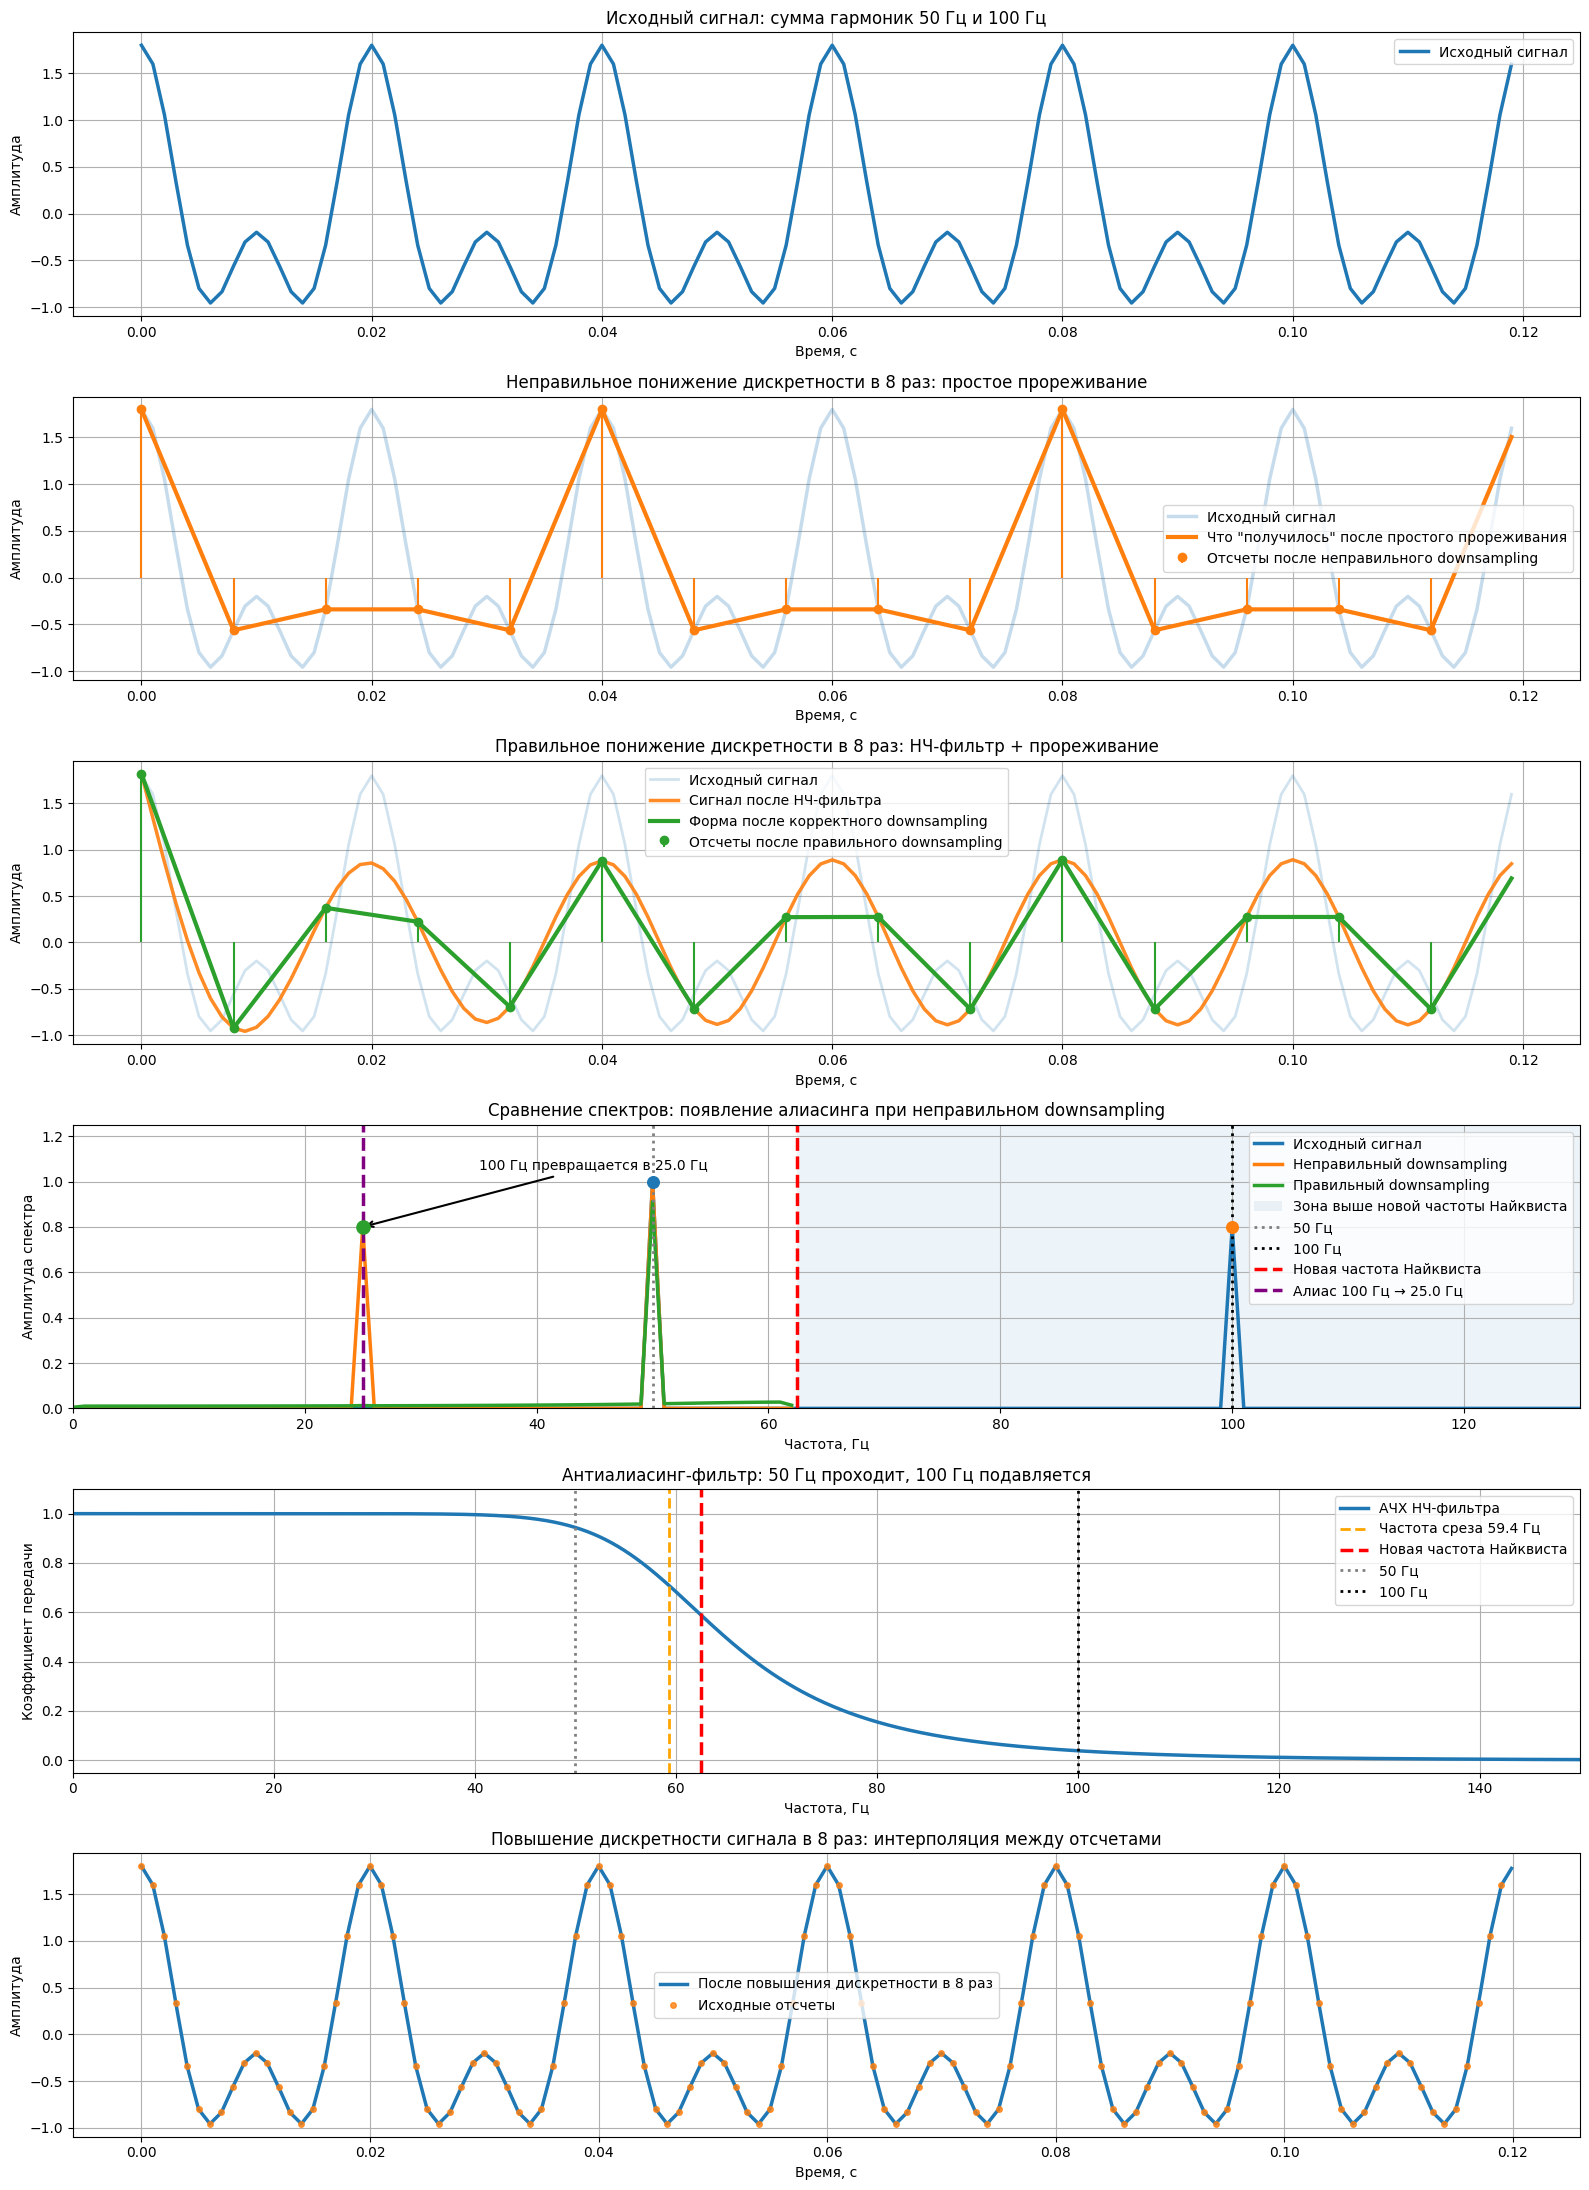

Исходная частота дискретизации: 1000 Гц
Новая частота дискретизации: 125.0 Гц
Новая частота Найквиста: 62.5 Гц
Частоты исходного сигнала: 50 Гц и 100 Гц
После алиасинга частота 100 Гц отображается как 25.0 Гц
Амплитуда 50 Гц в исходном сигнале: 1.000
Амплитуда 100 Гц в исходном сигнале: 0.800
Амплитуда алиаса 25.0 Гц после неправильного downsampling: 0.800
Амплитуда 50 Гц после правильного downsampling: 0.911


In [13]:
### Задание 4
# Понижение / повышение дискретности сигнала в N раз
# Улучшенная визуализация алиасинга

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz


fs4 = 1000                  # исходная частота дискретизации, Гц
T4 = 1.0                    # длительность, с
N4 = int(fs4 * T4)
t4 = np.arange(N4) / fs4

# Две гармоники: 50 Гц и 100 Гц
f1_4 = 50
f2_4 = 100
x4 = np.cos(2 * np.pi * f1_4 * t4) + 0.8 * np.cos(2 * np.pi * f2_4 * t4)

# Коэффициент изменения дискретности
M4 = 8
fs4_new = fs4 / M4
nyquist4_new = fs4_new / 2

x4_down_wrong = x4[::M4]
t4_down = t4[::M4]

x4_wrong_reconstructed = np.interp(t4, t4_down, x4_down_wrong)


cutoff4 = 0.95 * nyquist4_new
b4, a4 = butter(6, cutoff4 / (fs4 / 2), btype='low')

x4_prefiltered = filtfilt(b4, a4, x4)
x4_down_correct = x4_prefiltered[::M4]
x4_correct_reconstructed = np.interp(t4, t4_down, x4_down_correct)


fs4_up = fs4 * M4
N4_up = N4 * M4
t4_up = np.arange(N4_up) / fs4_up
x4_up = np.interp(t4_up, t4, x4)


def get_spectrum(signal, fs):
    freqs = np.fft.rfftfreq(len(signal), d=1 / fs)
    spec = np.abs(np.fft.rfft(signal)) / len(signal)

    if len(spec) > 2:
        spec[1:-1] *= 2

    return freqs, spec

freq4_orig, spec4_orig = get_spectrum(x4, fs4)
freq4_wrong, spec4_wrong = get_spectrum(x4_down_wrong, fs4_new)
freq4_corr, spec4_corr = get_spectrum(x4_down_correct, fs4_new)


def alias_frequency(f, fs_new):
    # Частота после свертки в диапазон [0, fs_new/2]
    f_mod = f % fs_new
    if f_mod > fs_new / 2:
        f_mod = fs_new - f_mod
    return f_mod

alias_f2_4 = alias_frequency(f2_4, fs4_new)

w4, h4 = freqz(b4, a4, worN=4096, fs=fs4)
filter_gain4 = np.abs(h4)

idx_50_orig4 = np.argmin(np.abs(freq4_orig - f1_4))
idx_100_orig4 = np.argmin(np.abs(freq4_orig - f2_4))

idx_25_wrong4 = np.argmin(np.abs(freq4_wrong - alias_f2_4))
idx_50_wrong4 = np.argmin(np.abs(freq4_wrong - f1_4))
idx_50_corr4 = np.argmin(np.abs(freq4_corr - f1_4))


fig, axes = plt.subplots(6, 1, figsize=(16, 22))

# Показываем небольшой временной фрагмент
fragment_time4 = 0.12
fragment_idx4 = int(fragment_time4 * fs4)
mask_down_fragment = t4_down < fragment_time4

# 1) Исходный сигнал
axes[0].plot(t4[:fragment_idx4], x4[:fragment_idx4], linewidth=2.5, label='Исходный сигнал')
axes[0].set_title('Исходный сигнал: сумма гармоник 50 Гц и 100 Гц')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

# 2) Неправильный downsampling
axes[1].plot(t4[:fragment_idx4], x4[:fragment_idx4], alpha=0.25, linewidth=2.5, label='Исходный сигнал')
axes[1].plot(
    t4[:fragment_idx4],
    x4_wrong_reconstructed[:fragment_idx4],
    linewidth=3,
    label='Что "получилось" после простого прореживания'
)
axes[1].stem(
    t4_down[mask_down_fragment],
    x4_down_wrong[mask_down_fragment],
    linefmt='C1-',
    markerfmt='C1o',
    basefmt=' ',
    label='Отсчеты после неправильного downsampling'
)
axes[1].set_title(f'Неправильное понижение дискретности в {M4} раз: простое прореживание')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

# 3) Правильный downsampling
axes[2].plot(
    t4[:fragment_idx4],
    x4[:fragment_idx4],
    alpha=0.20,
    linewidth=2,
    label='Исходный сигнал'
)
axes[2].plot(
    t4[:fragment_idx4],
    x4_prefiltered[:fragment_idx4],
    alpha=0.9,
    linewidth=2.5,
    label='Сигнал после НЧ-фильтра'
)
axes[2].plot(
    t4[:fragment_idx4],
    x4_correct_reconstructed[:fragment_idx4],
    linewidth=3,
    label='Форма после корректного downsampling'
)
axes[2].stem(
    t4_down[mask_down_fragment],
    x4_down_correct[mask_down_fragment],
    linefmt='C2-',
    markerfmt='C2o',
    basefmt=' ',
    label='Отсчеты после правильного downsampling'
)
axes[2].set_title(f'Правильное понижение дискретности в {M4} раз: НЧ-фильтр + прореживание')
axes[2].set_xlabel('Время, с')
axes[2].set_ylabel('Амплитуда')
axes[2].grid(True)
axes[2].legend()

# 4) Сравнение спектров
axes[3].plot(freq4_orig, spec4_orig, linewidth=2.5, label='Исходный сигнал')
axes[3].plot(freq4_wrong, spec4_wrong, linewidth=2.5, label='Неправильный downsampling')
axes[3].plot(freq4_corr, spec4_corr, linewidth=2.5, label='Правильный downsampling')

axes[3].axvspan(nyquist4_new, 130, alpha=0.08, label='Зона выше новой частоты Найквиста')
axes[3].axvline(f1_4, color='gray', linestyle=':', linewidth=2, label='50 Гц')
axes[3].axvline(f2_4, color='black', linestyle=':', linewidth=2, label='100 Гц')
axes[3].axvline(nyquist4_new, color='red', linestyle='--', linewidth=2.5, label='Новая частота Найквиста')
axes[3].axvline(alias_f2_4, color='purple', linestyle='--', linewidth=2.5,
                label=f'Алиас 100 Гц → {alias_f2_4:.1f} Гц')

axes[3].scatter([f1_4], [spec4_orig[idx_50_orig4]], s=70, zorder=5)
axes[3].scatter([f2_4], [spec4_orig[idx_100_orig4]], s=70, zorder=5)
axes[3].scatter([alias_f2_4], [spec4_wrong[idx_25_wrong4]], s=90, zorder=5)

axes[3].annotate(
    f'100 Гц превращается в {alias_f2_4:.1f} Гц',
    xy=(alias_f2_4, spec4_wrong[idx_25_wrong4]),
    xytext=(alias_f2_4 + 10, spec4_wrong[idx_25_wrong4] + 0.25),
    arrowprops=dict(arrowstyle='->', linewidth=1.5)
)

axes[3].set_xlim(0, 130)
axes[3].set_ylim(0, max(np.max(spec4_orig), np.max(spec4_wrong), np.max(spec4_corr)) * 1.25)
axes[3].set_title('Сравнение спектров: появление алиасинга при неправильном downsampling')
axes[3].set_xlabel('Частота, Гц')
axes[3].set_ylabel('Амплитуда спектра')
axes[3].grid(True)
axes[3].legend(loc='upper right')

# 5) АЧХ фильтра
axes[4].plot(w4, filter_gain4, linewidth=2.5, label='АЧХ НЧ-фильтра')
axes[4].axvline(cutoff4, color='orange', linestyle='--', linewidth=2, label=f'Частота среза {cutoff4:.1f} Гц')
axes[4].axvline(nyquist4_new, color='red', linestyle='--', linewidth=2.5, label='Новая частота Найквиста')
axes[4].axvline(f1_4, color='gray', linestyle=':', linewidth=2, label='50 Гц')
axes[4].axvline(f2_4, color='black', linestyle=':', linewidth=2, label='100 Гц')
axes[4].set_xlim(0, 150)
axes[4].set_ylim(-0.05, 1.1)
axes[4].set_title('Антиалиасинг-фильтр: 50 Гц проходит, 100 Гц подавляется')
axes[4].set_xlabel('Частота, Гц')
axes[4].set_ylabel('Коэффициент передачи')
axes[4].grid(True)
axes[4].legend()

# 6) Повышение дискретности
fragment_up_idx4 = int(fragment_time4 * fs4_up)

axes[5].plot(
    t4_up[:fragment_up_idx4],
    x4_up[:fragment_up_idx4],
    linewidth=2.5,
    label=f'После повышения дискретности в {M4} раз'
)
axes[5].plot(
    t4[:fragment_idx4],
    x4[:fragment_idx4],
    'o',
    alpha=0.8,
    markersize=4,
    label='Исходные отсчеты'
)
axes[5].set_title(f'Повышение дискретности сигнала в {M4} раз: интерполяция между отсчетами')
axes[5].set_xlabel('Время, с')
axes[5].set_ylabel('Амплитуда')
axes[5].grid(True)
axes[5].legend()

plt.tight_layout()
plt.show()

print(f'Исходная частота дискретизации: {fs4} Гц')
print(f'Новая частота дискретизации: {fs4_new} Гц')
print(f'Новая частота Найквиста: {nyquist4_new} Гц')
print(f'Частоты исходного сигнала: {f1_4} Гц и {f2_4} Гц')
print(f'После алиасинга частота {f2_4} Гц отображается как {alias_f2_4:.1f} Гц')
print(f'Амплитуда 50 Гц в исходном сигнале: {spec4_orig[idx_50_orig4]:.3f}')
print(f'Амплитуда 100 Гц в исходном сигнале: {spec4_orig[idx_100_orig4]:.3f}')
print(f'Амплитуда алиаса {alias_f2_4:.1f} Гц после неправильного downsampling: {spec4_wrong[idx_25_wrong4]:.3f}')
print(f'Амплитуда 50 Гц после правильного downsampling: {spec4_corr[idx_50_corr4]:.3f}')

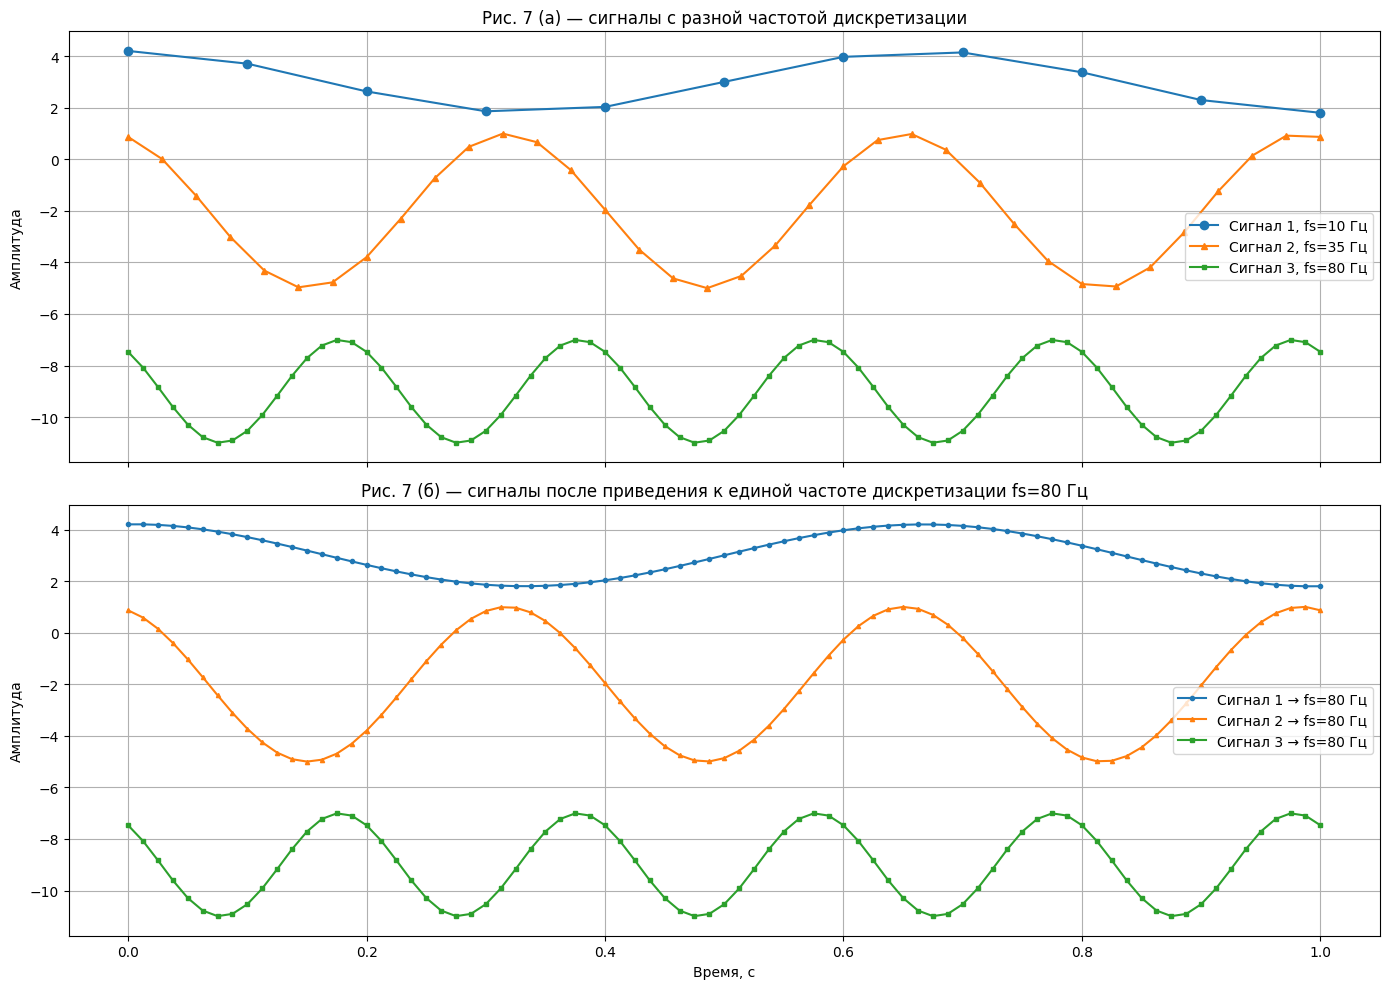

Исходные частоты дискретизации: 10, 35, 80 Гц
Общая частота дискретизации после приведения: 80 Гц
Количество точек до приведения: 11, 36, 81
Количество точек после приведения: 81, 81, 81


In [16]:
### Задание 5
# Приведение трех сигналов с разной частотой дискретизации к единой частоте

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


T5 = 1.0  # длительность, с

# Разные частоты дискретизации датчиков
fs1_5 = 10
fs2_5 = 35
fs3_5 = 80

# Частоты самих косинусоид
f1_5 = 1.5
f2_5 = 3.0
f3_5 = 5.0

t1_5 = np.arange(0, T5 + 1 / fs1_5, 1 / fs1_5)
t2_5 = np.arange(0, T5 + 1 / fs2_5, 1 / fs2_5)
t3_5 = np.arange(0, T5 + 1 / fs3_5, 1 / fs3_5)

t1_5 = t1_5[t1_5 <= T5]
t2_5 = t2_5[t2_5 <= T5]
t3_5 = t3_5[t3_5 <= T5]


x1_5 = 1.2 * np.cos(2 * np.pi * f1_5 * t1_5) + 3
x2_5 = 3.0 * np.cos(2 * np.pi * f2_5 * t2_5 + 0.3) - 2
x3_5 = 2.0 * np.cos(2 * np.pi * f3_5 * t3_5 + 0.7) - 9


fs_target5 = 80
t_target5 = np.arange(0, T5 + 1 / fs_target5, 1 / fs_target5)
t_target5 = t_target5[t_target5 <= T5]

# 5. Интерполяция на общую временную сетку
interp1_5 = interp1d(t1_5, x1_5, kind='cubic')
interp2_5 = interp1d(t2_5, x2_5, kind='cubic')
interp3_5 = interp1d(t3_5, x3_5, kind='cubic')

x1_target5 = interp1_5(t_target5)
x2_target5 = interp2_5(t_target5)
x3_target5 = interp3_5(t_target5)


fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Рис. 7 (а): до приведения к общей частоте
axes[0].plot(t1_5, x1_5, 'o-', label=f'Сигнал 1, fs={fs1_5} Гц', markersize=6)
axes[0].plot(t2_5, x2_5, '^-', label=f'Сигнал 2, fs={fs2_5} Гц', markersize=5)
axes[0].plot(t3_5, x3_5, 's-', label=f'Сигнал 3, fs={fs3_5} Гц', markersize=3)
axes[0].set_title('Рис. 7 (а) — сигналы с разной частотой дискретизации')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

# Рис. 7 (б): после приведения к общей частоте
axes[1].plot(t_target5, x1_target5, 'o-', label=f'Сигнал 1 → fs={fs_target5} Гц', markersize=3)
axes[1].plot(t_target5, x2_target5, '^-', label=f'Сигнал 2 → fs={fs_target5} Гц', markersize=3)
axes[1].plot(t_target5, x3_target5, 's-', label=f'Сигнал 3 → fs={fs_target5} Гц', markersize=3)
axes[1].set_title(f'Рис. 7 (б) — сигналы после приведения к единой частоте дискретизации fs={fs_target5} Гц')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


print(f'Исходные частоты дискретизации: {fs1_5}, {fs2_5}, {fs3_5} Гц')
print(f'Общая частота дискретизации после приведения: {fs_target5} Гц')
print(f'Количество точек до приведения: {len(t1_5)}, {len(t2_5)}, {len(t3_5)}')
print(f'Количество точек после приведения: {len(t_target5)}, {len(t_target5)}, {len(t_target5)}')